# Task a

In [1]:
import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt
import math

from collections.abc import Callable
from matplotlib.figure import Figure
from matplotlib.axes import Axes

In [2]:
def L(i: int, x_nodes: npt.NDArray[np.float64], x: npt.NDArray[np.float64]):
    L_i = np.ones_like(x, dtype = float)
    
    for j in range(len(x_nodes)):
        if j != i:
            L_i *= (x - x_nodes[j])/(x_nodes[i] - x_nodes[j])
    return L_i

def lagrange(x_nodes: npt.NDArray[np.float64], y_nodes: npt.NDArray[np.float64], x: npt.NDArray[np.float64]):
    p = np.zeros_like(x, dtype = float)
    for i in range(len(x_nodes)):
        p += y_nodes[i]*L(i, x_nodes, x)
        
    return p

def generate_equidistant_nodes(interval: tuple[float, float], n: int):
    return np.linspace(interval[0], interval[1], n + 1)

def generate_chebishev_nodes(n: int, interval: tuple[float, float]):
    i = np.arange(n + 1)
    nodes = np.cos((2 * i + 1) * np.pi / (2 * (n + 1)))
    
    a, b = interval
    return (b - a)*nodes/2 + (a + b)/2

def runge(x): return 1/(x**2 + 1)

def rel_l2_error(fun1: npt.NDArray[np.float64], fun2: npt.NDArray[np.float64]) -> float:
    return np.sqrt(np.sum((fun1 - fun2)**2)/sum(fun1**2))


In [3]:
def plot_chebishev_equidistant_lagrange(
    fun: Callable[[npt.NDArray[np.float64]], npt.NDArray[np.float64]], 
    interval: tuple[float, float], 
    n: int, 
    points: int = 1000,
    savefig: bool = False,
    ax: Axes|None = None,
    ) -> tuple[Figure, Axes, float, float]:
    standalone = ax is None
    
    if ax is None:
        fig, ax = plt.subplots(figsize = (8,4))
    else:
        fig = ax.figure
    
    x_arr = np.linspace(interval[0], interval[1], points)
    equidistant_nodes = generate_equidistant_nodes(interval = interval, n = n)
    chebishev_nodes = generate_chebishev_nodes(interval = interval, n = n)
    
    lagrange_equidistant = lagrange(equidistant_nodes, fun(equidistant_nodes), x_arr)
    lagrange_chebishev = lagrange(chebishev_nodes, fun(chebishev_nodes), x_arr)
    
    equidistant_rel_l2_error = rel_l2_error(fun(x_arr), lagrange_equidistant)
    chebishev_rel_l2_error = rel_l2_error(fun(x_arr), lagrange_chebishev)
    
    ax.plot(x_arr, lagrange_equidistant, label = "Equidistant nodes", linestyle = '--')
    ax.plot(x_arr, lagrange_chebishev, label = "Chebishev nodes", linestyle = '--')
    ax.plot(x_arr, fun(x_arr), label = "Runge function")
    
    error_text = (
        f'Rel. $L^2$ error \n'
        f'Equidistant: {equidistant_rel_l2_error:.2g}\n'
        f'Chebishev: {chebishev_rel_l2_error:.2g}\n'
    )
    
    #AI
    ax.text(
        0.02, 0.98,
        error_text,
        transform = ax.transAxes,
        verticalalignment = 'top',
        fontsize = 8,
        bbox = dict(boxstyle = "round", alpha = 0.8)
    )
    #AI
    
    if standalone:
        ax.set_title(f"Lagrange interpolation for Runge function on {interval} with {n + 1} nodes")
        ax.legend() 
    else:
        ax.set_title(f"n = {n}")
    
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    
    ax.grid()
   
    
    
    if savefig: fig.savefig(f'../outputs/lagrange_runge_{interval[0]}_{interval[1]}_{n}.png', bbox_inches = 'tight')
    
    return fig, ax, equidistant_rel_l2_error, chebishev_rel_l2_error

def plot_multiple_n(
    fun: Callable[[npt.NDArray[np.float64]], npt.NDArray[np.float64]], 
    interval: tuple[float, float],
    n_arr: list[int],
    points: int = 1000,
    savefig: bool = False,
) -> tuple[Figure, Axes, list[float], list[float]]:
    m = len(n_arr)
    
    ncols = math.ceil(math.sqrt(m))
    nrows = math.ceil(m / ncols)
    
    fig, axs = plt.subplots(
        nrows,
        ncols,
        figsize = (5 * ncols, 4 * nrows),
    )
    
    equidistant_error_arr = []
    chebishev_error_arr = []
    
    axs_flat = np.atleast_1d(axs).ravel()
    
    for ax, n in zip(axs_flat, n_arr):
        _, _, equidistant_error, chebishev_error = (
            plot_chebishev_equidistant_lagrange(
                fun = fun,
                interval = interval,
                n = n,
                points = points, 
                ax = ax,
            )
        )
        
        equidistant_error_arr.append(equidistant_error)
        chebishev_error_arr.append(chebishev_error)


    fig.suptitle(f"Lagrange interpolation of Runge function on [{interval[0]}, {interval[1]}]", fontsize = 16, y = 0.98)
    handles, lables = axs_flat[0].get_legend_handles_labels()
    
    fig.legend(handles, lables, loc = 'upper center', bbox_to_anchor = (0.5, 0.94), ncol = 3)
    fig.tight_layout(rect = (0, 0, 1, 0.95))
    
    for ax in axs_flat[len(n_arr):]:
        ax.set_visible(False)
    
    if savefig:
        fig.savefig(f"lagrange_runge_{interval[0]}_{interval[1]}_multiple_n.png", bbox_inches = 'tight')
        
    return fig, axs, equidistant_error_arr, chebishev_error_arr

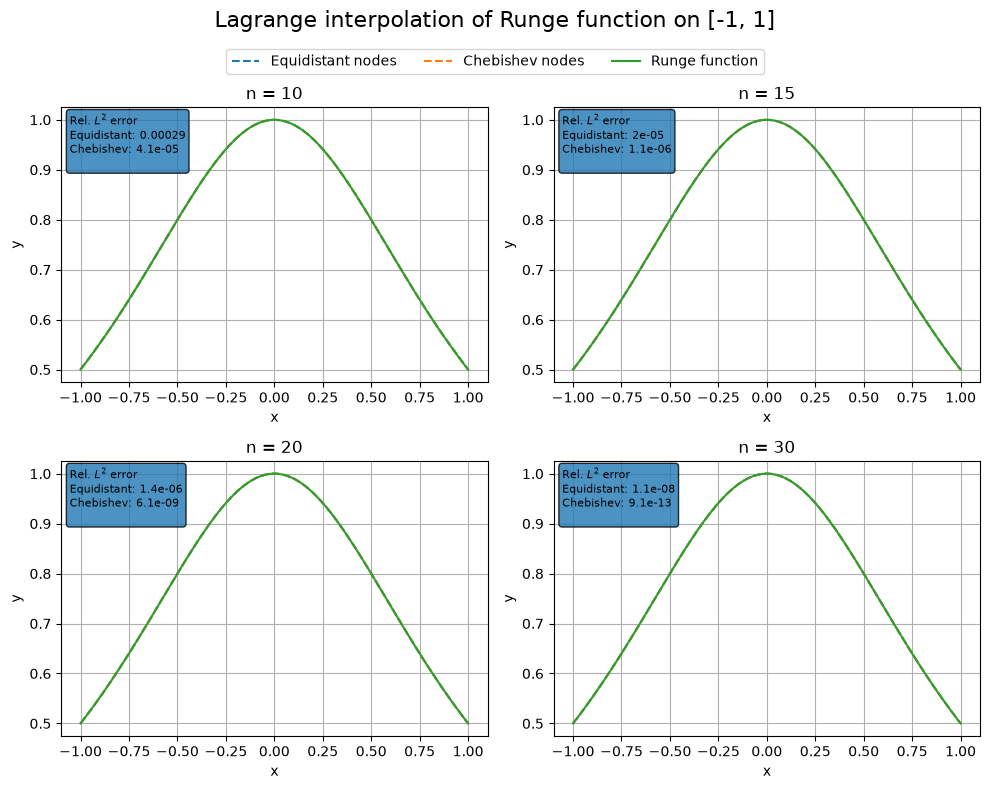

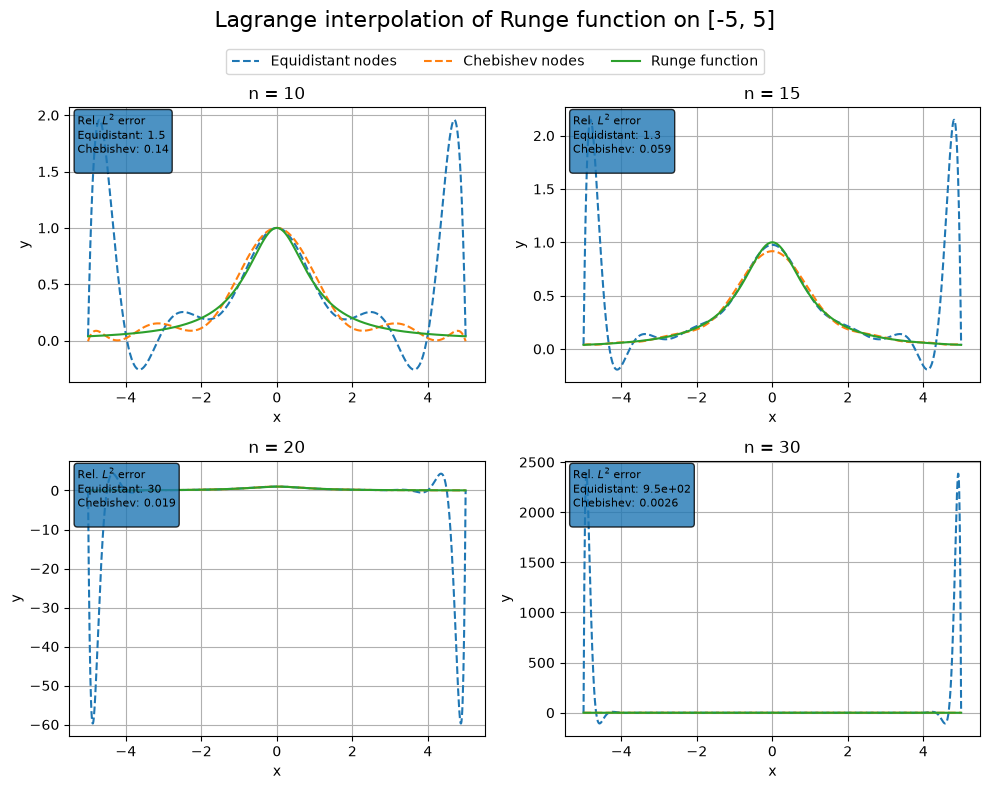

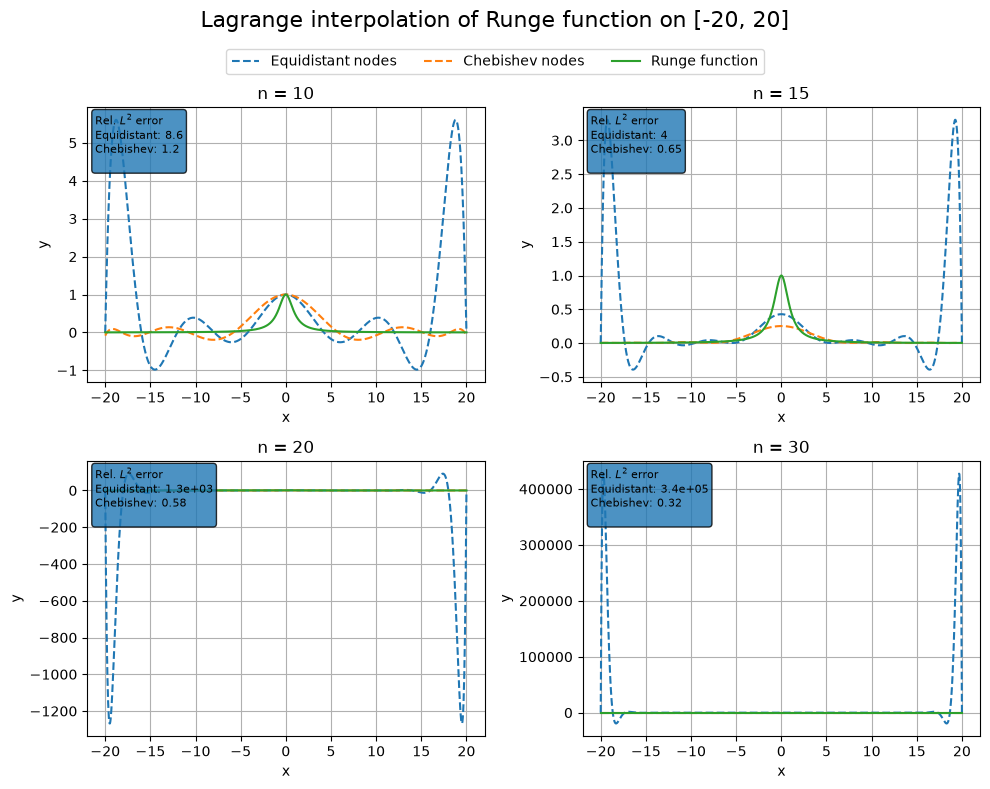

In [4]:
fig, axs, equidistant_error_arr, chebishev_error_arr = plot_multiple_n(fun = runge, interval = (-1, 1), n_arr = [10, 15, 20, 30])
fig, axs, equidistant_error_arr, chebishev_error_arr = plot_multiple_n(fun = runge, interval = (-5, 5), n_arr = [10, 15, 20, 30])
fig, axs, equidistant_error_arr, chebishev_error_arr = plot_multiple_n(fun = runge, interval = (-20, 20), n_arr = [10, 15, 20, 30])